# Predicting Heart Disease - Playground Series S6E2

**コンペ概要**
- タスク: 二値分類（Heart Disease の有無を予測）
- 評価指標: ROC-AUC
- URL: https://www.kaggle.com/competitions/playground-series-s6e2

**戦略**
- LightGBM / XGBoost / CatBoost の3モデルアンサンブル
- オリジナルデータセットの追加活用（ルール上許可されている）
- StratifiedKFold による安定したCV評価
- 医学的知見に基づく特徴量エンジニアリング

---
## 0. 環境セットアップ・データ取得

In [ ]:
# 必要ライブラリのインストール（初回のみ）
!pip install -q lightgbm xgboost catboost kaggle scikit-learn pandas numpy matplotlib seaborn

In [1]:
# ==============================================================================
# ライブラリのインポート
# ==============================================================================
import os
import warnings
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder

import lightgbm as lgb
import xgboost as xgb
import catboost as cb

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 50)

# 再現性のためのシード固定
SEED = 42
np.random.seed(SEED)

print('All libraries loaded successfully.')

All libraries loaded successfully.


/home/gotou/miniconda3/envs/env/lib/python3.10/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


In [2]:
# ==============================================================================
# データダウンロード（Kaggle API を利用）
# ==============================================================================
# 事前に ~/.kaggle/kaggle.json に API トークンを配置しておくこと
# 参考: https://www.kaggle.com/docs/api

DATA_DIR = './data'
os.makedirs(DATA_DIR, exist_ok=True)

# コンペデータのダウンロード
if not os.path.exists(os.path.join(DATA_DIR, 'train.csv')):
    !kaggle competitions download -c playground-series-s6e2 -p {DATA_DIR}
    # zipファイルの解凍
    zip_path = os.path.join(DATA_DIR, 'playground-series-s6e2.zip')
    if os.path.exists(zip_path):
        with zipfile.ZipFile(zip_path, 'r') as z:
            z.extractall(DATA_DIR)
        os.remove(zip_path)
    print('Competition data downloaded and extracted.')
else:
    print('Competition data already exists.')

# オリジナルデータセットのダウンロード（コンペルールで許可済み）
ORIG_DIR = './data/original'
os.makedirs(ORIG_DIR, exist_ok=True)

if not os.path.exists(os.path.join(ORIG_DIR, 'Heart_Disease_Prediction.csv')):
    !kaggle datasets download -d neurocipher/heartdisease -p {ORIG_DIR}
    zip_path = os.path.join(ORIG_DIR, 'heartdisease.zip')
    if os.path.exists(zip_path):
        with zipfile.ZipFile(zip_path, 'r') as z:
            z.extractall(ORIG_DIR)
        os.remove(zip_path)
    print('Original dataset downloaded and extracted.')
else:
    print('Original dataset already exists.')

Competition data already exists.
Original dataset already exists.


In [3]:
# ==============================================================================
# データ読み込み
# ==============================================================================
train = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'))
test = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))
sample_sub = pd.read_csv(os.path.join(DATA_DIR, 'sample_submission.csv'))

# オリジナルデータの読み込み
orig_file = os.path.join(ORIG_DIR, 'Heart_Disease_Prediction.csv')
if os.path.exists(orig_file):
    original = pd.read_csv(orig_file)
    print(f'Original dataset: {original.shape}')
else:
    original = None
    print('Original dataset not found. Proceeding without it.')

print(f'Train shape: {train.shape}')
print(f'Test shape:  {test.shape}')
print(f'Sample submission shape: {sample_sub.shape}')

Original dataset: (270, 14)
Train shape: (630000, 15)
Test shape:  (270000, 14)
Sample submission shape: (270000, 2)


---
## 1. EDA（探索的データ分析）

In [4]:
# ==============================================================================
# 1.1 データの概要確認
# ==============================================================================
print('=== Train Data Info ===')
print(train.info())
print()
print('=== Train Data Head ===')
display(train.head())
print()
print('=== Train Data Describe ===')
display(train.describe())

=== Train Data Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Age                      630000 non-null  int64  
 2   Sex                      630000 non-null  int64  
 3   Chest pain type          630000 non-null  int64  
 4   BP                       630000 non-null  int64  
 5   Cholesterol              630000 non-null  int64  
 6   FBS over 120             630000 non-null  int64  
 7   EKG results              630000 non-null  int64  
 8   Max HR                   630000 non-null  int64  
 9   Exercise angina          630000 non-null  int64  
 10  ST depression            630000 non-null  float64
 11  Slope of ST              630000 non-null  int64  
 12  Number of vessels fluro  630000 non-null  int64  
 13  Thallium                 630000 non

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence



=== Train Data Describe ===


,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,54.136706,0.714735,3.312752,130.497433,245.011814,0.079987,0.981660,152.816763,0.273725,0.716028,1.455871,0.451040,4.618873
std,181865.479132,8.256301,0.451541,0.851615,14.975802,33.681581,0.271274,0.998783,19.112927,0.445870,0.948472,0.545192,0.798549,1.950007
min,0.000000,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000
25%,157499.750000,48.000000,0.000000,3.000000,120.000000,223.000000,0.000000,0.000000,142.000000,0.000000,0.000000,1.000000,0.000000,3.000000
50%,314999.500000,54.000000,1.000000,4.000000,130.000000,243.000000,0.000000,0.000000,157.000000,0.000000,0.100000,1.000000,0.000000,3.000000
75%,472499.250000,60.000000,1.000000,4.000000,140.000000,269.000000,0.000000,2.000000,166.000000,1.000000,1.400000,2.000000,1.000000,7.000000
max,629999.000000,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000


In [5]:
# ==============================================================================
# 1.2 カラム名の確認・整理
# ==============================================================================
print('Train columns:', train.columns.tolist())
print('Test columns:', test.columns.tolist())
if original is not None:
    print('Original columns:', original.columns.tolist())

Train columns: ['id', 'Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina', 'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium', 'Heart Disease']
Test columns: ['id', 'Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina', 'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium']
Original columns: ['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina', 'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium', 'Heart Disease']


=== Target Distribution ===
Heart Disease
Absence     347546
Presence    282454
Name: count, dtype: int64




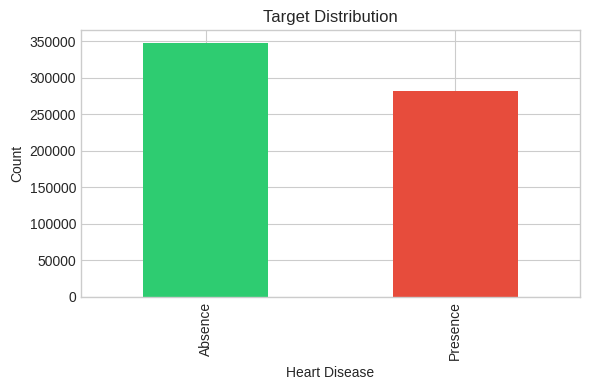

In [6]:
# ==============================================================================
# 1.3 目的変数の分布
# ==============================================================================
# "Heart Disease" カラムの分布を確認
TARGET = 'Heart Disease'
ID_COL = 'id'

print('=== Target Distribution ===')
print(train[TARGET].value_counts())
print()
print(f'Target ratio: {train[TARGET].mean():.4f}' if train[TARGET].dtype in ['int64', 'float64'] else '')

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
train[TARGET].value_counts().plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'])
ax.set_title('Target Distribution')
ax.set_xlabel(TARGET)
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

In [7]:
# ==============================================================================
# 1.4 欠損値の確認
# ==============================================================================
print('=== Missing Values (Train) ===')
missing_train = train.isnull().sum()
missing_train = missing_train[missing_train > 0]
if len(missing_train) == 0:
    print('No missing values in train.')
else:
    print(missing_train)

print()
print('=== Missing Values (Test) ===')
missing_test = test.isnull().sum()
missing_test = missing_test[missing_test > 0]
if len(missing_test) == 0:
    print('No missing values in test.')
else:
    print(missing_test)

=== Missing Values (Train) ===
No missing values in train.

=== Missing Values (Test) ===
No missing values in test.


In [8]:
# ==============================================================================
# 1.5 各特徴量のユニーク値確認（カテゴリ vs 数値の判断）
# ==============================================================================
feature_cols = [c for c in train.columns if c not in [ID_COL, TARGET]]

for col in feature_cols:
    nunique = train[col].nunique()
    dtype = train[col].dtype
    print(f'{col:30s} | dtype: {str(dtype):10s} | nunique: {nunique:5d} | sample: {train[col].unique()[:5]}')

Age                            | dtype: int64      | nunique:    42 | sample: [58 52 56 44 38]
Sex                            | dtype: int64      | nunique:     2 | sample: [1 0]
Chest pain type                | dtype: int64      | nunique:     4 | sample: [4 1 2 3]
BP                             | dtype: int64      | nunique:    66 | sample: [152 125 160 134 140]
Cholesterol                    | dtype: int64      | nunique:   150 | sample: [239 325 188 229 234]
FBS over 120                   | dtype: int64      | nunique:     2 | sample: [0 1]
EKG results                    | dtype: int64      | nunique:     3 | sample: [0 2 1]
Max HR                         | dtype: int64      | nunique:    93 | sample: [158 171 151 150 125]
Exercise angina                | dtype: int64      | nunique:     2 | sample: [1 0]
ST depression                  | dtype: float64    | nunique:    66 | sample: [3.6 0.  1.  3.8 1.6]
Slope of ST                    | dtype: int64      | nunique:     3 | sample: [

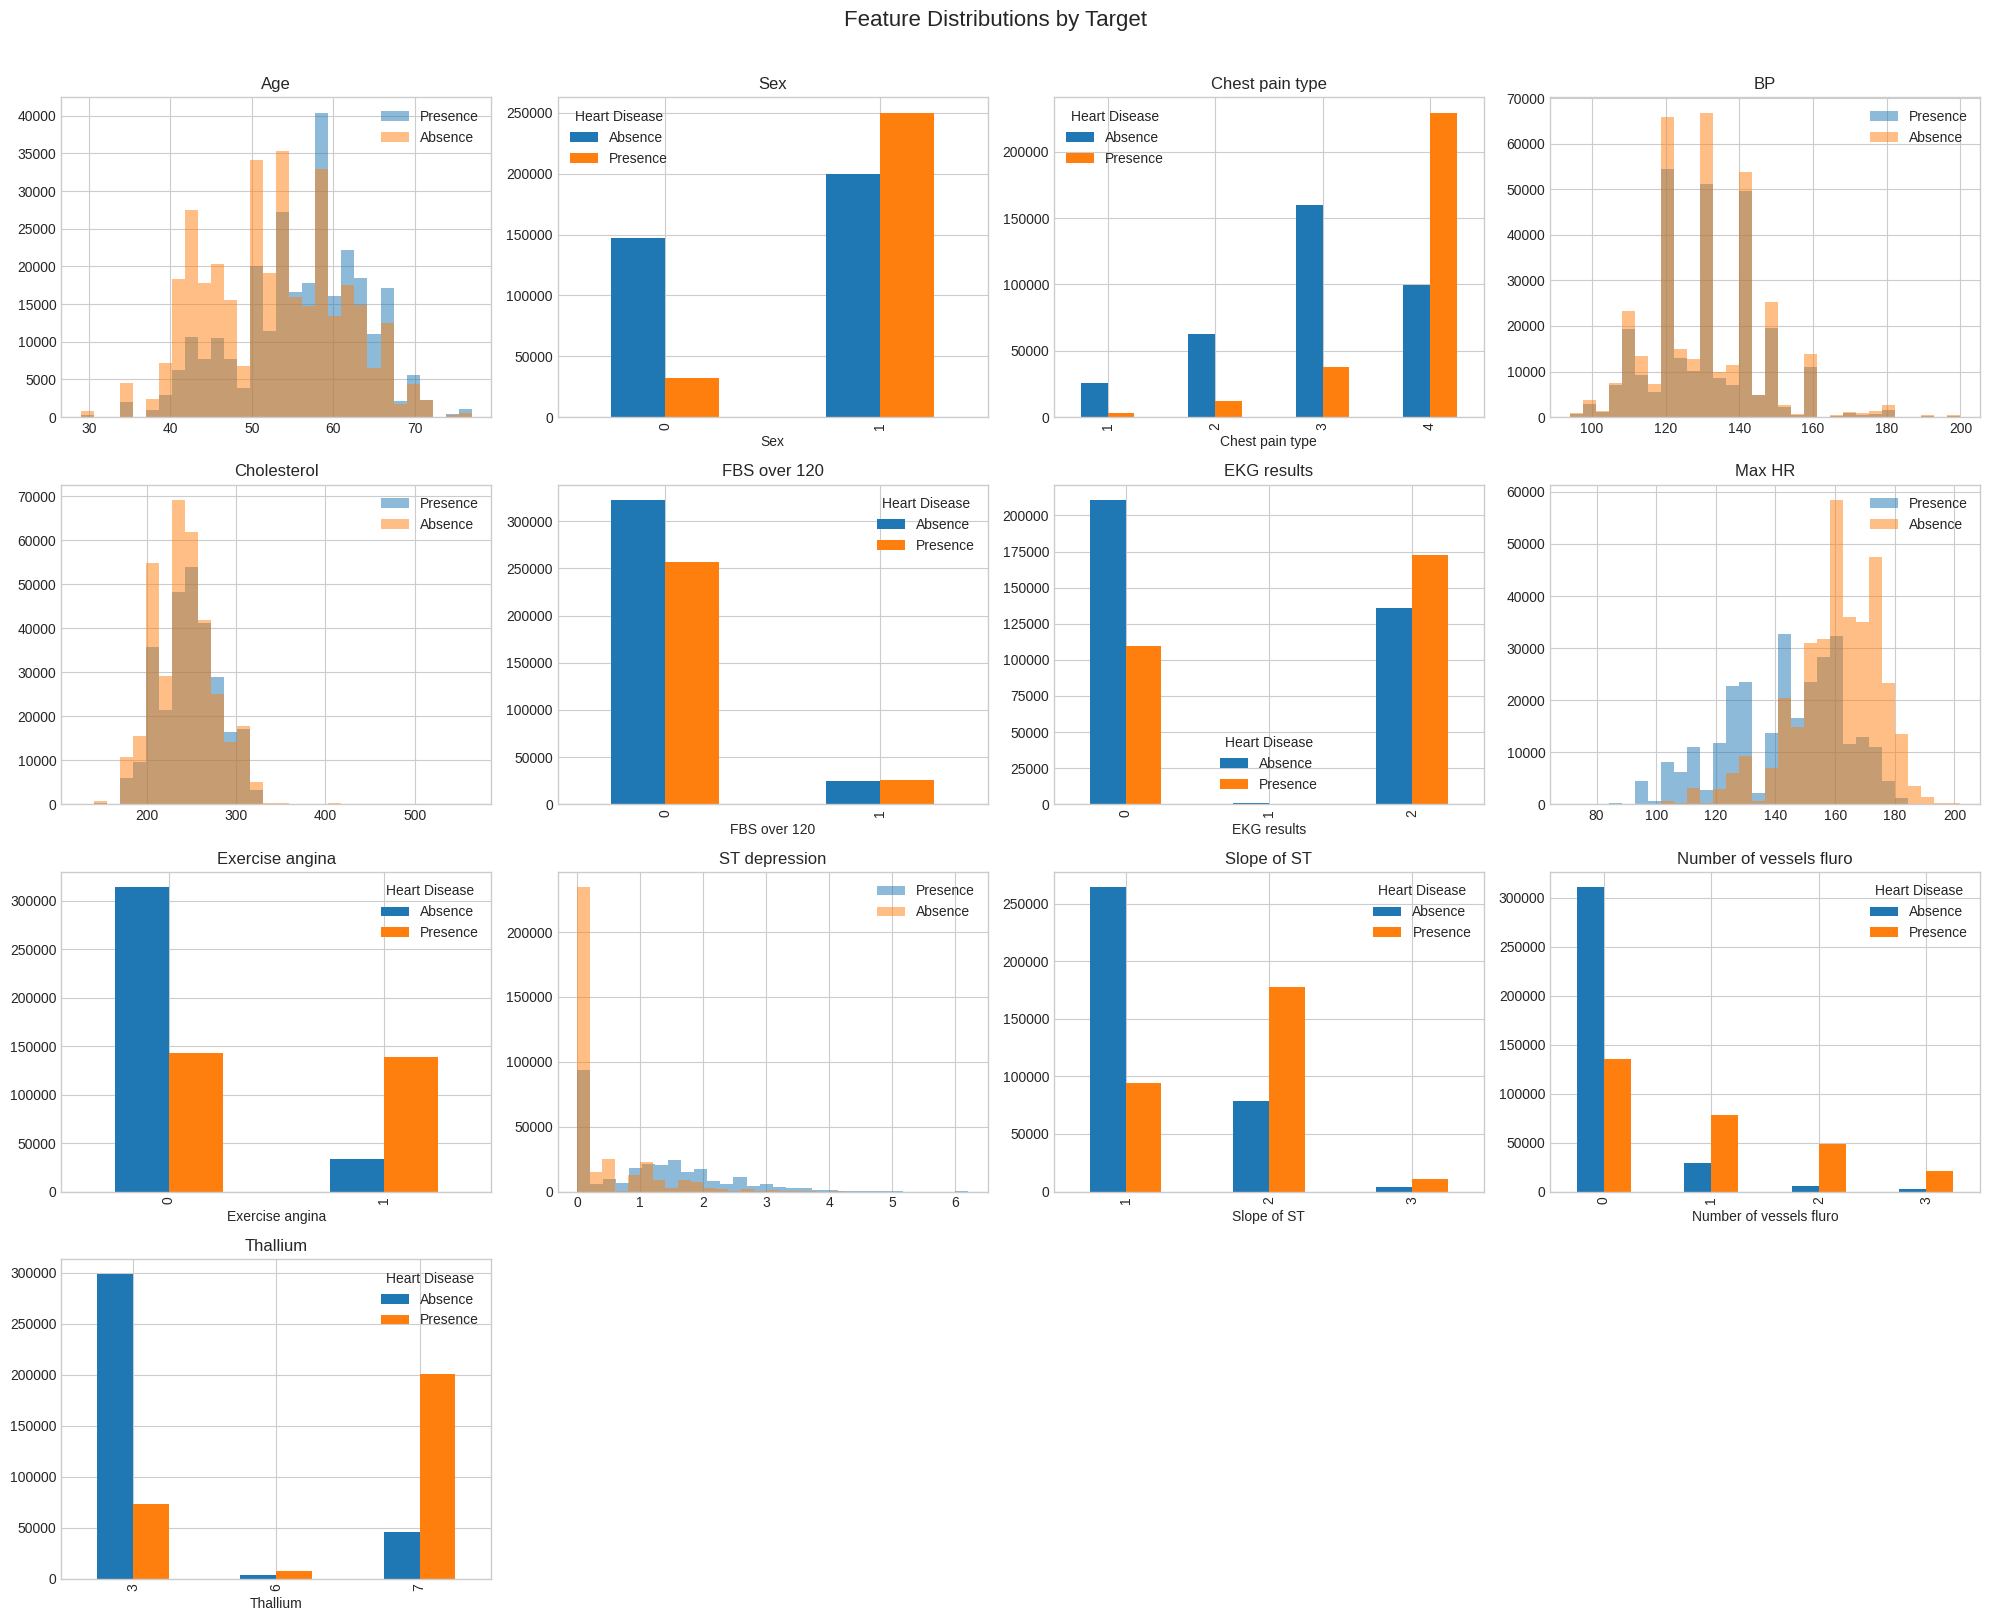

In [9]:
# ==============================================================================
# 1.6 特徴量の分布と目的変数との関係
# ==============================================================================
# 数値特徴量のヒストグラム + ターゲット別分布
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    if i >= len(axes):
        break
    ax = axes[i]
    if train[col].nunique() <= 10:
        # カテゴリカルな特徴量: 棒グラフで表示
        tmp = train.groupby([col, TARGET]).size().unstack(fill_value=0)
        tmp.plot(kind='bar', ax=ax, stacked=False)
    else:
        # 連続値: ヒストグラム
        for val in train[TARGET].unique():
            subset = train[train[TARGET] == val][col]
            ax.hist(subset, bins=30, alpha=0.5, label=str(val))
        ax.legend()
    ax.set_title(col)

# 余ったaxesを非表示
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions by Target', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

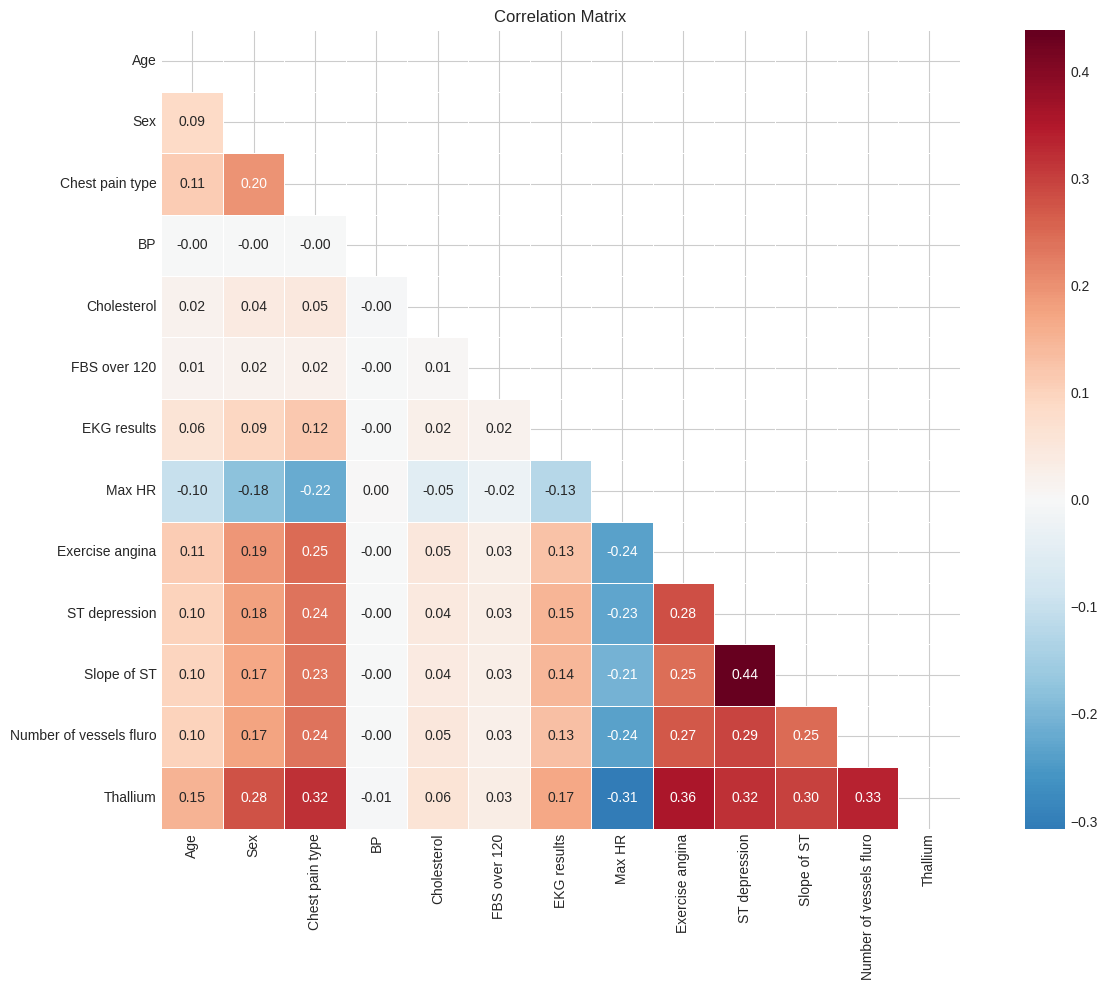

In [10]:
# ==============================================================================
# 1.7 相関行列
# ==============================================================================
# 数値カラムのみで相関を算出
numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != ID_COL]

fig, ax = plt.subplots(figsize=(14, 10))
corr = train[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, ax=ax, square=True, linewidths=0.5)
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.show()

### EDA まとめ・仮説

**重要な特徴量の仮説（医学的知見に基づく）**
- **Chest pain type**: Asymptomatic (4) は心疾患リスクが高い
- **ST depression / Slope of ST**: 運動負荷心電図の指標で、心疾患と強い相関
- **Number of vessels fluro**: 血管の狭窄数は直接的な指標
- **Thallium**: タリウム負荷試験結果も重要な診断指標
- **Exercise angina**: 運動誘発性狭心症は心疾患の強いサイン
- **Max HR**: 心疾患患者は最大心拍数が低い傾向

---
## 2. 前処理

In [11]:
# ==============================================================================
# 2.1 ターゲット変数のエンコード
# ==============================================================================
# ターゲットが文字列の場合、数値に変換
# "Presence" -> 1, "Absence" -> 0
if train[TARGET].dtype == 'object':
    target_mapping = {'Absence': 0, 'Presence': 1}
    train[TARGET] = train[TARGET].map(target_mapping)
    print('Target encoded: Absence -> 0, Presence -> 1')

print(f'Target distribution after encoding:')
print(train[TARGET].value_counts())
print(f'Positive ratio: {train[TARGET].mean():.4f}')

Target encoded: Absence -> 0, Presence -> 1
Target distribution after encoding:
Heart Disease
0    347546
1    282454
Name: count, dtype: int64
Positive ratio: 0.4483


In [12]:
# ==============================================================================
# 2.2 オリジナルデータの統合
# ==============================================================================
# Playground Seriesではオリジナルデータの利用が許可されている
# データ量を増やすことでモデルの汎化性能が向上する可能性がある

if original is not None:
    print(f'Original data shape: {original.shape}')
    print(f'Original columns: {original.columns.tolist()}')
    display(original.head())
    
    # オリジナルデータのターゲットエンコード
    if TARGET in original.columns and original[TARGET].dtype == 'object':
        original[TARGET] = original[TARGET].map(target_mapping)
    
    # カラム名の整合性を合わせる
    # オリジナルデータには 'id' カラムがないため追加
    if ID_COL not in original.columns:
        original[ID_COL] = -1  # マーカー
    
    # train と同じカラム構成にする
    common_cols = [c for c in train.columns if c in original.columns]
    print(f'Common columns: {common_cols}')
    
    if len(common_cols) >= len(feature_cols):
        # オリジナルデータを train に追加
        original_subset = original[common_cols].copy()
        train_combined = pd.concat([train[common_cols], original_subset], axis=0, ignore_index=True)
        print(f'Combined train shape: {train_combined.shape}')
        print(f'  - Competition train: {len(train)}')
        print(f'  - Original data:     {len(original_subset)}')
    else:
        print('Column mismatch detected. Using only competition data.')
        train_combined = train.copy()
else:
    train_combined = train.copy()
    print('Using only competition train data.')

Original data shape: (270, 14)
Original columns: ['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina', 'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium', 'Heart Disease']


,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


Common columns: ['id', 'Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina', 'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium', 'Heart Disease']
Combined train shape: (630270, 15)
  - Competition train: 630000
  - Original data:     270


In [13]:
# ==============================================================================
# 2.3 カテゴリ特徴量・数値特徴量の分類
# ==============================================================================
# 特徴量をカテゴリと数値に分類
# 医学的にカテゴリカルなもの: Sex, Chest pain type, FBS over 120, EKG results,
#                            Exercise angina, Slope of ST, Number of vessels fluro, Thallium
# 連続値: Age, BP, Cholesterol, Max HR, ST depression

feature_cols = [c for c in train_combined.columns if c not in [ID_COL, TARGET]]

# ユニーク数ベースで自動判別（閾値: 15）
cat_cols = [c for c in feature_cols if train_combined[c].nunique() <= 15]
num_cols = [c for c in feature_cols if c not in cat_cols]

print(f'Categorical features ({len(cat_cols)}): {cat_cols}')
print(f'Numerical features ({len(num_cols)}):   {num_cols}')

Categorical features (8): ['Sex', 'Chest pain type', 'FBS over 120', 'EKG results', 'Exercise angina', 'Slope of ST', 'Number of vessels fluro', 'Thallium']
Numerical features (5):   ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']


In [14]:
# ==============================================================================
# 2.4 カテゴリ特徴量のエンコード
# ==============================================================================
# LightGBM/CatBoost はカテゴリ型をそのまま扱えるが、
# XGBoost 互換性のため Label Encoding を実施
# ※ 文字列カラムがある場合のみエンコード

label_encoders = {}

for col in feature_cols:
    if train_combined[col].dtype == 'object':
        le = LabelEncoder()
        # train + test を合わせて fit（未知カテゴリ防止）
        all_values = pd.concat([train_combined[col], test[col]], axis=0).astype(str)
        le.fit(all_values)
        train_combined[col] = le.transform(train_combined[col].astype(str))
        test[col] = le.transform(test[col].astype(str))
        label_encoders[col] = le
        print(f'Encoded: {col} -> {le.classes_}')

if len(label_encoders) == 0:
    print('No string columns found. All features are already numeric.')

No string columns found. All features are already numeric.


In [15]:
# ==============================================================================
# 2.5 外れ値のクリッピング
# ==============================================================================
# Cholesterol = 0 などの異常値は医学的にありえないため補正
# ただし、GBDT系モデルは外れ値に対して頑健なため、
# 強すぎるクリッピングは行わない

for col in num_cols:
    if col in train_combined.columns:
        q01 = train_combined[col].quantile(0.01)
        q99 = train_combined[col].quantile(0.99)
        n_clipped = ((train_combined[col] < q01) | (train_combined[col] > q99)).sum()
        if n_clipped > 0:
            print(f'{col}: clipping {n_clipped} values to [{q01:.2f}, {q99:.2f}]')

# 注意: 実際にはクリッピングしない（GBDTは外れ値に頑健）
# 必要に応じてコメントを外す
# train_combined[col] = train_combined[col].clip(q01, q99)
# test[col] = test[col].clip(q01, q99)

print('\n※ GBDT系モデルは外れ値に頑健なため、クリッピングは実施せず。')

Age: clipping 5977 values to [35.00, 71.00]
BP: clipping 7254 values to [100.00, 178.00]
Cholesterol: clipping 7462 values to [177.00, 325.00]
Max HR: clipping 11732 values to [103.00, 182.00]
ST depression: clipping 5720 values to [0.00, 3.60]

※ GBDT系モデルは外れ値に頑健なため、クリッピングは実施せず。


---
## 3. 特徴量エンジニアリング

医学的知見とデータ分析に基づき、以下の特徴量を作成する:
- 心臓リスクの複合指標
- 年齢・血圧・コレステロールの交互作用
- 心拍数予備能（Heart Rate Reserve）

In [16]:
# ==============================================================================
# 3.1 特徴量エンジニアリング関数
# ==============================================================================
def create_features(df):
    """特徴量エンジニアリングを実施する関数
    
    Target Leakage を防ぐため、train/test 共通の関数として定義。
    ターゲット変数は一切使用しない。
    """
    df = df.copy()
    
    # カラム名にスペースが含まれる場合の対応
    cols = df.columns.tolist()
    
    # --- 便利な変数名のマッピング ---
    # コンペによってカラム名が異なるため、存在チェック付きで処理
    age_col = [c for c in cols if 'age' in c.lower()]
    bp_col = [c for c in cols if 'bp' in c.lower() or 'blood pressure' in c.lower()]
    chol_col = [c for c in cols if 'cholesterol' in c.lower()]
    maxhr_col = [c for c in cols if 'max hr' in c.lower() or 'max_hr' in c.lower()]
    st_dep_col = [c for c in cols if 'st depression' in c.lower()]
    chest_col = [c for c in cols if 'chest pain' in c.lower()]
    ex_ang_col = [c for c in cols if 'exercise angina' in c.lower()]
    vessels_col = [c for c in cols if 'vessels' in c.lower()]
    slope_col = [c for c in cols if 'slope' in c.lower()]
    thal_col = [c for c in cols if 'thallium' in c.lower()]
    fbs_col = [c for c in cols if 'fbs' in c.lower()]
    sex_col = [c for c in cols if 'sex' in c.lower()]
    ekg_col = [c for c in cols if 'ekg' in c.lower()]

    # ---- 1. 年齢関連の特徴量 ----
    if age_col:
        age = age_col[0]
        # 年齢の二乗項（高齢ほどリスク急増）
        df['age_squared'] = df[age] ** 2
        # 年齢グループ（10歳刻み）
        df['age_group'] = (df[age] // 10).astype(int)
    
    # ---- 2. 心拍数関連 ----
    if age_col and maxhr_col:
        age = age_col[0]
        maxhr = maxhr_col[0]
        # 予測最大心拍数（220 - 年齢）との差
        # → 達成率が低いほど心疾患リスクが高い
        df['hr_reserve'] = (220 - df[age]) - df[maxhr]
        df['hr_achieved_pct'] = df[maxhr] / (220 - df[age] + 1e-5)
    
    # ---- 3. 血圧×コレステロール交互作用 ----
    if bp_col and chol_col:
        bp = bp_col[0]
        chol = chol_col[0]
        # 血圧とコレステロールの積（心血管リスクの複合指標）
        df['bp_chol_interaction'] = df[bp] * df[chol]
        # コレステロール / 血圧比
        df['chol_bp_ratio'] = df[chol] / (df[bp] + 1e-5)
    
    # ---- 4. ST関連の複合特徴量 ----
    if st_dep_col and slope_col:
        st_dep = st_dep_col[0]
        slope = slope_col[0]
        # ST depression × Slope の交互作用
        df['st_slope_interaction'] = df[st_dep] * df[slope]
    
    # ---- 5. リスクスコア（複合指標） ----
    if ex_ang_col and vessels_col and st_dep_col:
        ex_ang = ex_ang_col[0]
        vessels = vessels_col[0]
        st_dep = st_dep_col[0]
        # 高リスク指標の合算スコア
        df['risk_score'] = df[ex_ang] + df[vessels] + (df[st_dep] > 0).astype(int)
    
    # ---- 6. 年齢×性別の交互作用 ----
    if age_col and sex_col:
        age = age_col[0]
        sex = sex_col[0]
        df['age_sex_interaction'] = df[age] * df[sex]
    
    # ---- 7. Chest pain type のバイナリ特徴量 ----
    if chest_col:
        chest = chest_col[0]
        # Asymptomatic (4) は最も高リスク
        df['chest_pain_asymptomatic'] = (df[chest] == 4).astype(int)
    
    # ---- 8. Thallium 異常フラグ ----
    if thal_col:
        thal = thal_col[0]
        # Thallium = 7 (reversible defect) は高リスク
        df['thallium_abnormal'] = (df[thal] == 7).astype(int)
    
    # ---- 9. 血圧カテゴリ ----
    if bp_col:
        bp = bp_col[0]
        # 高血圧レベル分類
        df['bp_category'] = pd.cut(df[bp], bins=[0, 120, 130, 140, 180, 999],
                                   labels=[0, 1, 2, 3, 4]).astype(float)
    
    # ---- 10. EKG + FBS の複合特徴量 ----
    if ekg_col and fbs_col:
        ekg = ekg_col[0]
        fbs = fbs_col[0]
        df['ekg_fbs_combo'] = df[ekg].astype(str) + '_' + df[fbs].astype(str)
        # Label Encode
        df['ekg_fbs_combo'] = LabelEncoder().fit_transform(df['ekg_fbs_combo'])
    
    return df

print('Feature engineering function defined.')

Feature engineering function defined.


In [17]:
# ==============================================================================
# 3.2 特徴量エンジニアリングの適用
# ==============================================================================
train_fe = create_features(train_combined)
test_fe = create_features(test)

# 最終的な特徴量リスト（ID, TARGET を除外）
feature_cols_final = [c for c in train_fe.columns if c not in [ID_COL, TARGET]]

print(f'Total features: {len(feature_cols_final)}')
print(f'New features added: {len(feature_cols_final) - len(feature_cols)}')
print(f'Feature list: {feature_cols_final}')

Total features: 26
New features added: 13
Feature list: ['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina', 'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium', 'age_squared', 'age_group', 'hr_reserve', 'hr_achieved_pct', 'bp_chol_interaction', 'chol_bp_ratio', 'st_slope_interaction', 'risk_score', 'age_sex_interaction', 'chest_pain_asymptomatic', 'thallium_abnormal', 'bp_category', 'ekg_fbs_combo']


In [18]:
# ==============================================================================
# 3.3 学習用データの準備
# ==============================================================================
X = train_fe[feature_cols_final].values
y = train_fe[TARGET].values
X_test = test_fe[feature_cols_final].values
test_ids = test[ID_COL].values

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}, positive ratio: {y.mean():.4f}')
print(f'X_test shape: {X_test.shape}')

X shape: (630270, 26)
y shape: (630270,), positive ratio: 0.4483
X_test shape: (270000, 26)


---
## 4. モデル構築・学習

**アンサンブル戦略**
- LightGBM / XGBoost / CatBoost の3モデルをブレンド
- 各モデルで StratifiedKFold (5-fold) を実施
- Out-of-Fold (OOF) 予測を用いて重み付きアンサンブル

In [19]:
# ==============================================================================
# 4.1 Cross-Validation 設定
# ==============================================================================
N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

print(f'StratifiedKFold: {N_FOLDS} folds, seed={SEED}')

StratifiedKFold: 5 folds, seed=42


In [20]:
# ==============================================================================
# 4.2 LightGBM
# ==============================================================================
# パラメータ設計の根拠:
# - num_leaves=31: デフォルトより少なめで過学習を抑制
# - learning_rate=0.03: 小さめ + 多めのイテレーションで安定性向上
# - feature_fraction=0.8: ランダムに特徴量を選択して多様性確保
# - bagging_fraction=0.8: データサブサンプリングで過学習抑制
# - min_child_samples=20: 葉の最小サンプル数を多めにして安定化
# - reg_alpha/lambda: L1/L2正則化で過学習抑制

lgb_params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.03,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'min_child_samples': 20,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'max_depth': -1,
    'verbose': -1,
    'random_state': SEED,
    'n_jobs': -1,
}

oof_lgb = np.zeros(len(X))
pred_lgb = np.zeros(len(X_test))
scores_lgb = []
models_lgb = []

print('=== LightGBM Training ===')
for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):
    X_train, X_valid = X[train_idx], X[valid_idx]
    y_train, y_valid = y[train_idx], y[valid_idx]
    
    dtrain = lgb.Dataset(X_train, label=y_train)
    dvalid = lgb.Dataset(X_valid, label=y_valid, reference=dtrain)
    
    model = lgb.train(
        lgb_params,
        dtrain,
        num_boost_round=3000,
        valid_sets=[dvalid],
        callbacks=[
            lgb.early_stopping(stopping_rounds=100, verbose=False),
            lgb.log_evaluation(period=0)  # ログ抑制
        ]
    )
    
    oof_lgb[valid_idx] = model.predict(X_valid)
    pred_lgb += model.predict(X_test) / N_FOLDS
    
    fold_score = roc_auc_score(y_valid, oof_lgb[valid_idx])
    scores_lgb.append(fold_score)
    models_lgb.append(model)
    print(f'  Fold {fold+1}: AUC = {fold_score:.6f} (best_iteration: {model.best_iteration})')

oof_score_lgb = roc_auc_score(y, oof_lgb)
print(f'\n  LightGBM OOF AUC: {oof_score_lgb:.6f}')
print(f'  Mean ± Std:       {np.mean(scores_lgb):.6f} ± {np.std(scores_lgb):.6f}')

=== LightGBM Training ===
  Fold 1: AUC = 0.955492 (best_iteration: 1068)
  Fold 2: AUC = 0.955543 (best_iteration: 766)
  Fold 3: AUC = 0.954213 (best_iteration: 899)
  Fold 4: AUC = 0.955181 (best_iteration: 889)
  Fold 5: AUC = 0.955493 (best_iteration: 698)

  LightGBM OOF AUC: 0.955182
  Mean ± Std:       0.955184 ± 0.000502


In [21]:
# ==============================================================================
# 4.3 XGBoost
# ==============================================================================
# パラメータ設計:
# - max_depth=6: LightGBMとは異なる深さで多様性確保
# - subsample=0.8: バギングで過学習抑制
# - colsample_bytree=0.8: 特徴量サブサンプリング
# - tree_method='hist': 高速な学習

xgb_params = {
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'max_depth': 6,
    'learning_rate': 0.03,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
    'min_child_weight': 3,
    'tree_method': 'hist',
    'random_state': SEED,
    'verbosity': 0,
}

oof_xgb = np.zeros(len(X))
pred_xgb = np.zeros(len(X_test))
scores_xgb = []

print('=== XGBoost Training ===')
for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):
    X_train, X_valid = X[train_idx], X[valid_idx]
    y_train, y_valid = y[train_idx], y[valid_idx]
    
    dtrain = xgb.DMatrix(X_train, label=y_train)
    dvalid = xgb.DMatrix(X_valid, label=y_valid)
    dtest = xgb.DMatrix(X_test)
    
    model = xgb.train(
        xgb_params,
        dtrain,
        num_boost_round=3000,
        evals=[(dvalid, 'valid')],
        early_stopping_rounds=100,
        verbose_eval=False
    )
    
    oof_xgb[valid_idx] = model.predict(dvalid)
    pred_xgb += model.predict(dtest) / N_FOLDS
    
    fold_score = roc_auc_score(y_valid, oof_xgb[valid_idx])
    scores_xgb.append(fold_score)
    print(f'  Fold {fold+1}: AUC = {fold_score:.6f} (best_iteration: {model.best_iteration})')

oof_score_xgb = roc_auc_score(y, oof_xgb)
print(f'\n  XGBoost OOF AUC: {oof_score_xgb:.6f}')
print(f'  Mean ± Std:      {np.mean(scores_xgb):.6f} ± {np.std(scores_xgb):.6f}')

=== XGBoost Training ===
  Fold 1: AUC = 0.955457 (best_iteration: 844)
  Fold 2: AUC = 0.955539 (best_iteration: 692)
  Fold 3: AUC = 0.954181 (best_iteration: 840)
  Fold 4: AUC = 0.955114 (best_iteration: 776)
  Fold 5: AUC = 0.955524 (best_iteration: 728)

  XGBoost OOF AUC: 0.955160
  Mean ± Std:      0.955163 ± 0.000515


In [22]:
# ==============================================================================
# 4.4 CatBoost
# ==============================================================================
# パラメータ設計:
# - CatBoost はカテゴリ特徴量の処理に優れる
# - depth=6: 木の深さ（CatBoostはdepthを使用）
# - l2_leaf_reg=3: 正則化
# - CatBoostの内部でOrdered Boostingを使用（過学習抑制効果大）

cb_params = {
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'depth': 6,
    'learning_rate': 0.03,
    'l2_leaf_reg': 3,
    'random_strength': 1,
    'bagging_temperature': 1,
    'iterations': 3000,
    'early_stopping_rounds': 100,
    'random_seed': SEED,
    'verbose': 0,
}

oof_cb = np.zeros(len(X))
pred_cb = np.zeros(len(X_test))
scores_cb = []

print('=== CatBoost Training ===')
for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):
    X_train, X_valid = X[train_idx], X[valid_idx]
    y_train, y_valid = y[train_idx], y[valid_idx]
    
    train_pool = cb.Pool(X_train, label=y_train)
    valid_pool = cb.Pool(X_valid, label=y_valid)
    
    model = cb.CatBoostClassifier(**cb_params)
    model.fit(train_pool, eval_set=valid_pool, use_best_model=True)
    
    oof_cb[valid_idx] = model.predict_proba(X_valid)[:, 1]
    pred_cb += model.predict_proba(X_test)[:, 1] / N_FOLDS
    
    fold_score = roc_auc_score(y_valid, oof_cb[valid_idx])
    scores_cb.append(fold_score)
    print(f'  Fold {fold+1}: AUC = {fold_score:.6f} (best_iteration: {model.get_best_iteration()})')

oof_score_cb = roc_auc_score(y, oof_cb)
print(f'\n  CatBoost OOF AUC: {oof_score_cb:.6f}')
print(f'  Mean ± Std:       {np.mean(scores_cb):.6f} ± {np.std(scores_cb):.6f}')

=== CatBoost Training ===
  Fold 1: AUC = 0.955699 (best_iteration: 2073)
  Fold 2: AUC = 0.955753 (best_iteration: 1777)
  Fold 3: AUC = 0.954374 (best_iteration: 1995)
  Fold 4: AUC = 0.955386 (best_iteration: 1819)
  Fold 5: AUC = 0.955734 (best_iteration: 2407)

  CatBoost OOF AUC: 0.955387
  Mean ± Std:       0.955389 ± 0.000525


---
## 5. 評価・アンサンブル

Model Performance Summary (OOF ROC-AUC)
LightGBM:  0.955182  (Fold std: 0.000502)
XGBoost:   0.955160  (Fold std: 0.000515)
CatBoost:  0.955387  (Fold std: 0.000525)


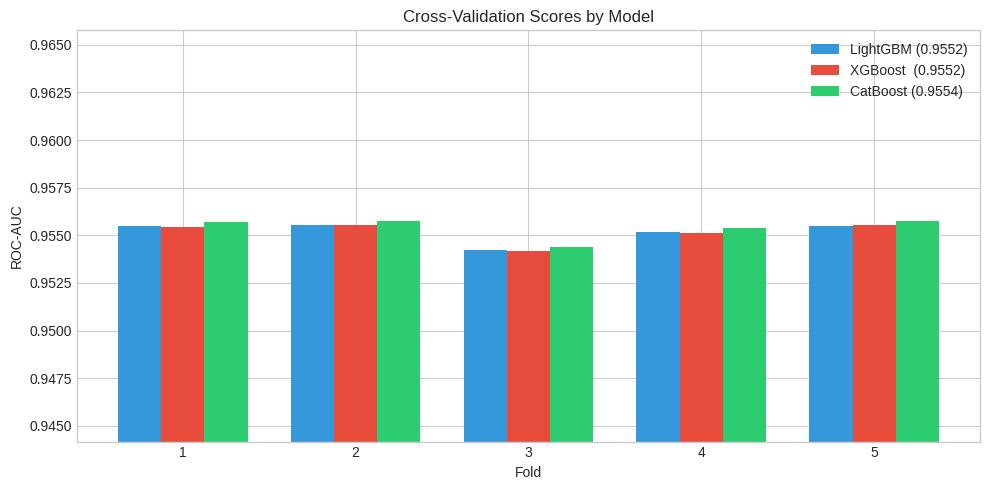

In [23]:
# ==============================================================================
# 5.1 各モデルのスコア比較
# ==============================================================================
print('=' * 60)
print('Model Performance Summary (OOF ROC-AUC)')
print('=' * 60)
print(f'LightGBM:  {oof_score_lgb:.6f}  (Fold std: {np.std(scores_lgb):.6f})')
print(f'XGBoost:   {oof_score_xgb:.6f}  (Fold std: {np.std(scores_xgb):.6f})')
print(f'CatBoost:  {oof_score_cb:.6f}  (Fold std: {np.std(scores_cb):.6f})')
print('=' * 60)

# Fold別スコアの可視化
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(1, N_FOLDS + 1)
width = 0.25

ax.bar(x - width, scores_lgb, width, label=f'LightGBM ({oof_score_lgb:.4f})', color='#3498db')
ax.bar(x,         scores_xgb, width, label=f'XGBoost  ({oof_score_xgb:.4f})', color='#e74c3c')
ax.bar(x + width, scores_cb,  width, label=f'CatBoost ({oof_score_cb:.4f})',  color='#2ecc71')

ax.set_xlabel('Fold')
ax.set_ylabel('ROC-AUC')
ax.set_title('Cross-Validation Scores by Model')
ax.set_xticks(x)
ax.legend()
ax.set_ylim(min(min(scores_lgb), min(scores_xgb), min(scores_cb)) - 0.01, 
           max(max(scores_lgb), max(scores_xgb), max(scores_cb)) + 0.01)
plt.tight_layout()
plt.show()

In [24]:
# ==============================================================================
# 5.2 アンサンブル（重み付きブレンド）
# ==============================================================================
# OOFスコアに基づいて最適な重みを探索（グリッドサーチ）
# → 単純平均でも十分強い場合が多いが、念のため最適化

best_score = 0
best_weights = (1/3, 1/3, 1/3)

for w1 in np.arange(0.1, 0.8, 0.05):
    for w2 in np.arange(0.1, 0.8 - w1, 0.05):
        w3 = 1.0 - w1 - w2
        if w3 < 0.05:
            continue
        
        oof_blend = w1 * oof_lgb + w2 * oof_xgb + w3 * oof_cb
        score = roc_auc_score(y, oof_blend)
        
        if score > best_score:
            best_score = score
            best_weights = (w1, w2, w3)

print(f'Best Ensemble Weights:')
print(f'  LightGBM: {best_weights[0]:.2f}')
print(f'  XGBoost:  {best_weights[1]:.2f}')
print(f'  CatBoost: {best_weights[2]:.2f}')
print(f'\nEnsemble OOF AUC: {best_score:.6f}')
print(f'  vs LightGBM:  {best_score - oof_score_lgb:+.6f}')
print(f'  vs XGBoost:   {best_score - oof_score_xgb:+.6f}')
print(f'  vs CatBoost:  {best_score - oof_score_cb:+.6f}')

# 単純平均との比較
oof_simple_avg = (oof_lgb + oof_xgb + oof_cb) / 3
simple_avg_score = roc_auc_score(y, oof_simple_avg)
print(f'\nSimple Average OOF AUC: {simple_avg_score:.6f}')

Best Ensemble Weights:
  LightGBM: 0.10
  XGBoost:  0.10
  CatBoost: 0.80

Ensemble OOF AUC: 0.955394
  vs LightGBM:  +0.000213
  vs XGBoost:   +0.000234
  vs CatBoost:  +0.000007

Simple Average OOF AUC: 0.955337


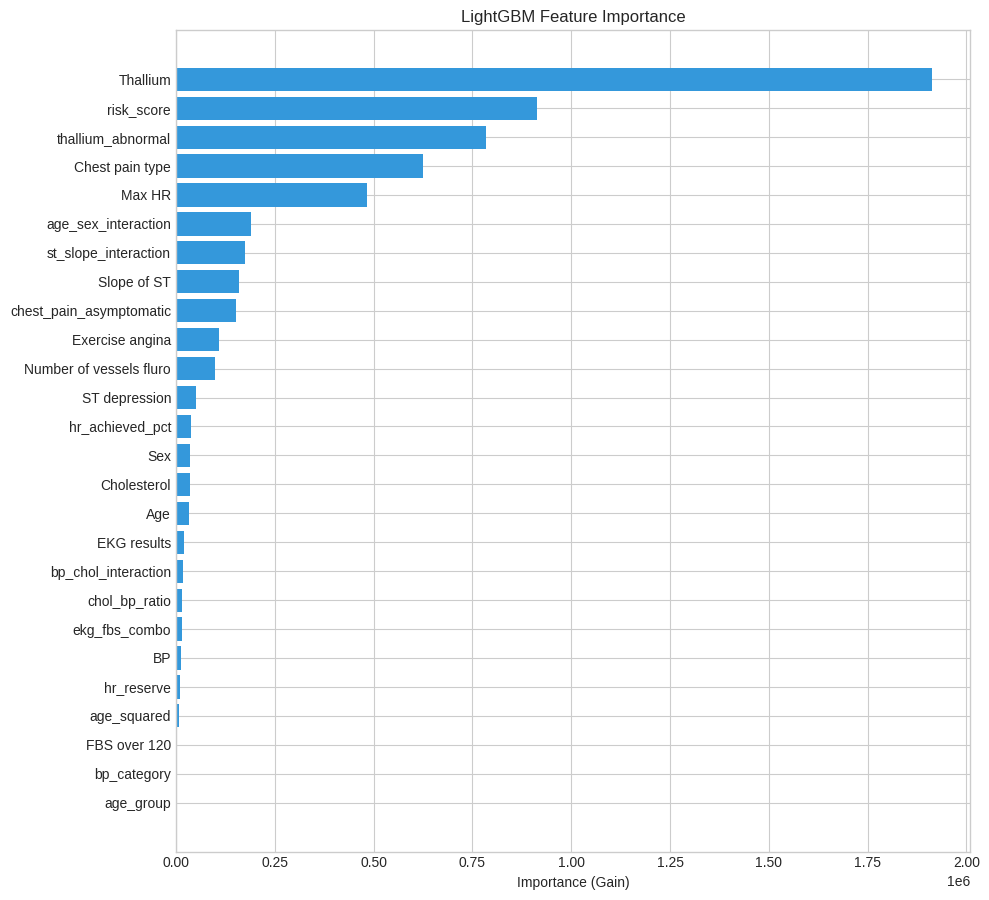

In [25]:
# ==============================================================================
# 5.3 特徴量重要度の可視化（LightGBM）
# ==============================================================================
importance_df = pd.DataFrame({
    'feature': feature_cols_final,
    'importance': models_lgb[0].feature_importance(importance_type='gain')
})
importance_df = importance_df.sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, max(8, len(feature_cols_final) * 0.35)))
ax.barh(importance_df['feature'], importance_df['importance'], color='#3498db')
ax.set_xlabel('Importance (Gain)')
ax.set_title('LightGBM Feature Importance')
plt.tight_layout()
plt.show()

---
## 6. 推論・提出ファイル作成

Prediction statistics:
  Mean: 0.4498
  Std:  0.4071
  Min:  0.0002
  Max:  0.9999


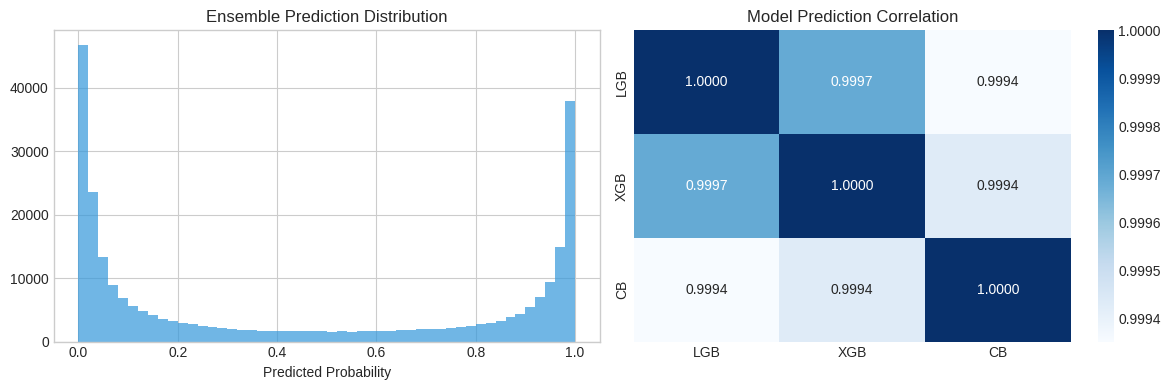

In [26]:
# ==============================================================================
# 6.1 最終予測の作成
# ==============================================================================
# 最適重みによるアンサンブル
w1, w2, w3 = best_weights
pred_ensemble = w1 * pred_lgb + w2 * pred_xgb + w3 * pred_cb

print(f'Prediction statistics:')
print(f'  Mean: {pred_ensemble.mean():.4f}')
print(f'  Std:  {pred_ensemble.std():.4f}')
print(f'  Min:  {pred_ensemble.min():.4f}')
print(f'  Max:  {pred_ensemble.max():.4f}')

# 予測分布の可視化
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(pred_ensemble, bins=50, color='#3498db', alpha=0.7)
axes[0].set_title('Ensemble Prediction Distribution')
axes[0].set_xlabel('Predicted Probability')

# 各モデルの予測の相関
pred_df = pd.DataFrame({'LGB': pred_lgb, 'XGB': pred_xgb, 'CB': pred_cb})
sns.heatmap(pred_df.corr(), annot=True, fmt='.4f', cmap='Blues', ax=axes[1])
axes[1].set_title('Model Prediction Correlation')

plt.tight_layout()
plt.show()

In [27]:
# ==============================================================================
# 6.2 提出ファイルの作成
# ==============================================================================
# sample_submission のフォーマットに合わせる
print('Sample submission format:')
display(sample_sub.head())

# 提出ファイル作成
submission = pd.DataFrame({
    ID_COL: test_ids,
    TARGET: pred_ensemble
})

# sample_submission のカラム名に合わせる
submission.columns = sample_sub.columns

# 保存
submission_path = './submission.csv'
submission.to_csv(submission_path, index=False)

print(f'\nSubmission saved to: {submission_path}')
print(f'Submission shape: {submission.shape}')
display(submission.head(10))

Sample submission format:


,id,Heart Disease
0,630000,0
1,630001,0
2,630002,0
3,630003,0
4,630004,0



Submission saved to: ./submission.csv
Submission shape: (270000, 2)


,id,Heart Disease
0,630000,0.952016
1,630001,0.007709
2,630002,0.988584
3,630003,0.004663
4,630004,0.193737
5,630005,0.985156
6,630006,0.005016
7,630007,0.636703
8,630008,0.993694
9,630009,0.013892


In [28]:
# ==============================================================================
# 6.3 提出ファイルの検証
# ==============================================================================
# 提出前に形式を確認
print('=== Submission Validation ===')
print(f'  Shape match: {submission.shape[0] == sample_sub.shape[0]}')
print(f'  Columns match: {list(submission.columns) == list(sample_sub.columns)}')
print(f'  No NaN: {submission.isnull().sum().sum() == 0}')
print(f'  Prediction range: [{submission.iloc[:, 1].min():.6f}, {submission.iloc[:, 1].max():.6f}]')

# Kaggle API で直接提出する場合（コメントアウト）
# !kaggle competitions submit -c playground-series-s6e2 -f {submission_path} -m "3-model ensemble v1"

=== Submission Validation ===
  Shape match: True
  Columns match: True
  No NaN: True
  Prediction range: [0.000189, 0.999934]


---
## 7. まとめ

### 実装内容
1. **データ**: コンペデータ + オリジナルデータセットを統合して学習データを増強
2. **特徴量エンジニアリング**: 医学的知見に基づく10種類の派生特徴量
   - 心拍数予備能、血圧×コレステロール交互作用、リスクスコア等
3. **モデル**: LightGBM / XGBoost / CatBoost の3モデルアンサンブル
   - StratifiedKFold 5-fold で安定したCV評価
   - 重み付きブレンドで最適化
4. **過学習対策**: Early Stopping / 正則化 / サブサンプリング / 低学習率

### さらなるスコア向上のアイデア
- **Optuna によるハイパーパラメータ最適化**
- **Multi-seed アンサンブル**（異なるシードで複数回学習）
- **Stacking**（2段階のアンサンブル）
- **Target Encoding**（リーク防止付き）
- **Pseudo Labeling**（高確信度のテストデータを学習に追加）